In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

In [2]:
sb.set(font_scale=1.0, style='white')

In [3]:
table = pd.read_csv('/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/table_statistics/10-validation-iter-table.csv')
table.head()

,Experiment,Dataset,Precision,Recall
0,Iter 1,BBBC039,0.61,0.86
1,Iter 1,Pilot_Screen,0.78,0.95
2,Iter 1,HeLa_RPE1,0.79,0.95
3,Iter 1,MNFinder Data,0.80,0.82
4,Iter 2,BBBC039,0.69,0.68


Precision

<Axes: xlabel='Dataset', ylabel='Precision'>

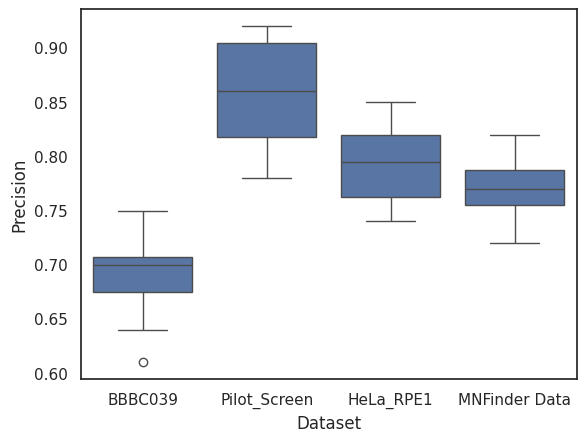

In [25]:
sb.boxplot(data=table,
             x='Dataset',
             y='Precision')

<Axes: xlabel='Dataset', ylabel='Recall'>

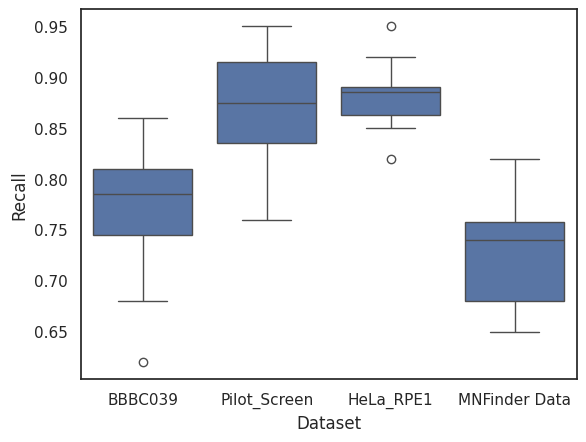

In [26]:
sb.boxplot(data=table,
             x='Dataset',
             y='Recall')

In [4]:
table_2 = table[['Experiment', 'Precision', 'Recall']]
table_2.head()

,Experiment,Precision,Recall
0,Iter 1,0.61,0.86
1,Iter 1,0.78,0.95
2,Iter 1,0.79,0.95
3,Iter 1,0.80,0.82
4,Iter 2,0.69,0.68


In [5]:
summary = table_2.groupby('Experiment', as_index=False).mean()
summary

,Experiment,Precision,Recall
0,Iter 1,0.7450,0.8950
1,Iter 10 (v1),0.8075,0.7925
2,Iter 2,0.8000,0.7350
3,Iter 3,0.8050,0.7850
4,Iter 4,0.7500,0.8100
5,Iter 5,0.7425,0.8250
6,Iter 6,0.7775,0.8050
7,Iter 7,0.8250,0.7625
8,Iter 8,0.7450,0.8800
9,Iter 9,0.7850,0.8350


<Axes: xlabel='Precision', ylabel='Recall'>

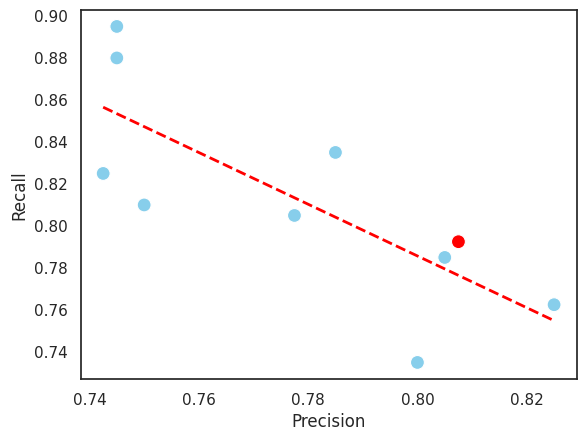

In [6]:
palette_colors = {exp: 'skyblue' for exp in summary['Experiment'].unique()}
palette_colors['Iter 10 (v1)'] = 'red'

ax = sb.scatterplot(data=summary,
               x='Precision',
               y='Recall',
               hue='Experiment',
               palette=palette_colors,
               s=100,
               legend=False)
sb.regplot(data=summary,
           x='Precision',
               y='Recall',
           scatter=False, 
           ax=ax, 
           color='red',
           ci=None,
           line_kws={"linewidth": 2,
                     "linestyle": "--"})

In [27]:
from scipy import stats

r, p_value = stats.pearsonr(summary['Precision'], summary['Recall'])

print(f"Pearson Correlation (r): {r:.4f}")
print(f"P-value: {p_value:.4e}")

Pearson Correlation (r): -0.7730
P-value: 8.7350e-03
